# Step 1: Project Setup and Data Loading

In this section, we will load all four datasets:
- `data.csv`: Main dataset for training and EDA
- `Task2_superheroes_villains.csv`: Unseen characters for prediction
- `Task2_matches.csv`: Matchups to predict outcomes for
- `Task3_villain.csv`: Single unbeatable villain for analysis

We will inspect their structure, check for missing values, and prepare for further analysis.


In [ ]:
import pandas as pd

# Load all datasets
main_data = pd.read_csv(r"C:\Users\niyim\Downloads\kddm_grouproject\data.csv")
task2_data = pd.read_csv(r"C:\Users\niyim\Downloads\kddm_grouproject\Task2_superheroes_villains.csv")
task2_matches = pd.read_csv(r"C:\Users\niyim\Downloads\kddm_grouproject\Task2_matches.csv")
task3_villain = pd.read_csv(r"C:\Users\niyim\Downloads\kddm_grouproject\Task3_villain.csv")

# Display shape and columns
#print("Main Dataset:")
#print(main_data.shape)
#print(main_data.columns.tolist(), "\n")

#print("Task 2 Superheroes/Villains:")
#print(task2_data.shape)
#print(task2_data.columns.tolist(), "\n")

#print("Task 2 Matches:")
#print(task2_matches.shape)
#print(task2_matches.columns.tolist(), "\n")

#print("Task 3 Villain:")
#print(task3_villain.shape)
#print(task3_villain.columns.tolist())'''


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\niyim\\Downloads\\kddm_grouproject\\data.csv'

# Step 2: Exploratory Data Analysis (EDA)

The goal of this section is to explore and understand the structure, quality, and trends in the main dataset (`data.csv`). We will:
- Check for missing values
- Visualize distributions of numerical and categorical features
- Analyze correlations with the target (`win_prob`)
- Detect outliers


In [ ]:
# Quick overview
main_data.info()

# Count of missing values
missing_values = main_data.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1036 non-null   object 
 1   role            1036 non-null   object 
 2   skin_type       1036 non-null   object 
 3   power_level     977 non-null    float64
 4   weight          969 non-null    float64
 5   height          1023 non-null   float64
 6   age             1036 non-null   float64
 7   eye_color       704 non-null    object 
 8   gender          865 non-null    float64
 9   hair_color      940 non-null    object 
 10  speed           758 non-null    float64
 11  universe        1036 non-null   object 
 12  body_type       1036 non-null   object 
 13  job             1036 non-null   object 
 14  battle_iq       1036 non-null   float64
 15  species         1011 non-null   object 
 16  ranking         1036 non-null   float64
 17  intelligence    965 non-null    f

secret_code       388
eye_color         337
speed             283
gender            176
hair_color        101
training_time      96
intelligence       76
weight             72
power_level        64
species            30
height             18
age                 5
name                5
role                5
skin_type           5
battle_iq           5
job                 5
body_type           5
universe            5
abilities           5
ranking             5
special_attack      5
win_prob            5
dtype: int64

In [ ]:
missing_values.to_csv(r'C:\Users\niyim\Downloads\kddm_grouproject\cleaned_dataset.csv', index=False)

## Distribution of Numerical Features

Here we plot histograms of numeric features to observe their spread, skewness, and detect potential anomalies.


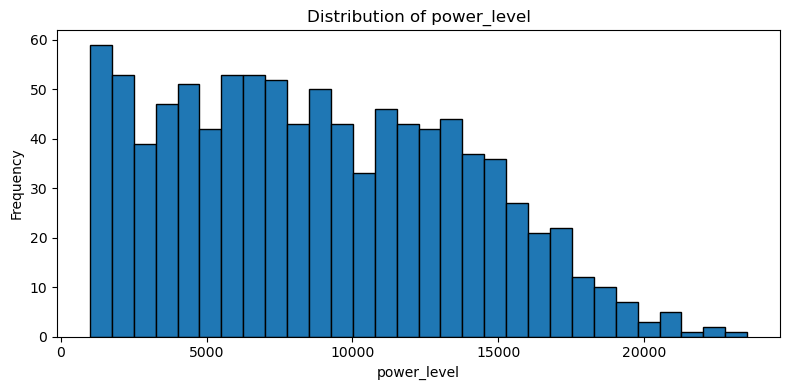

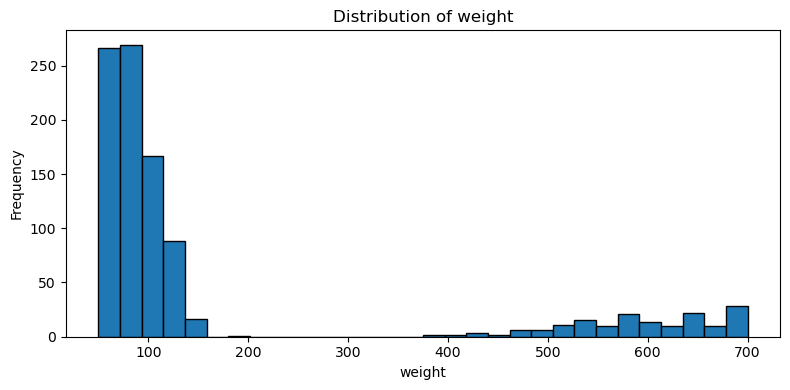

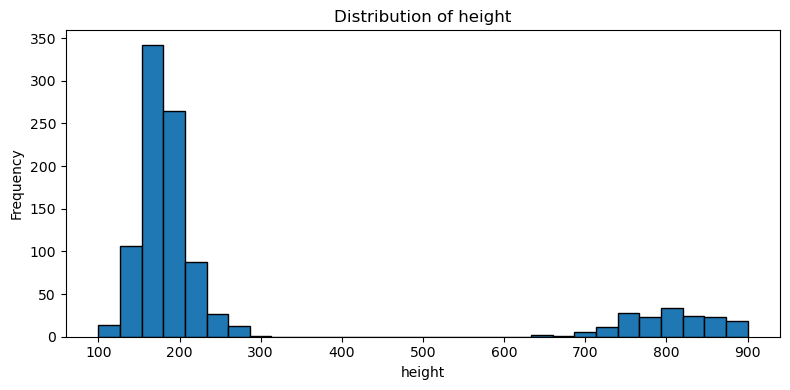

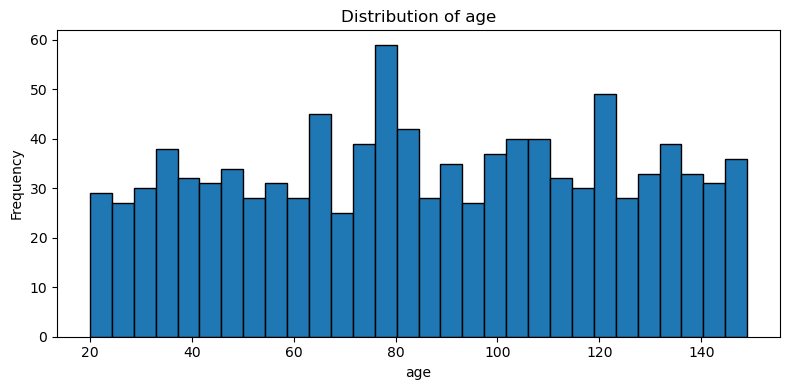

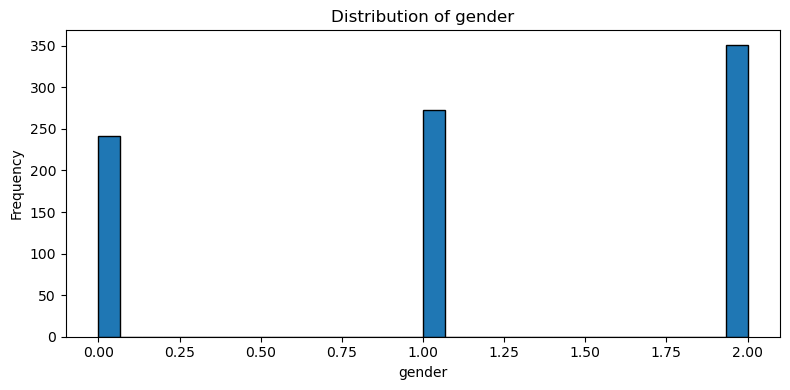

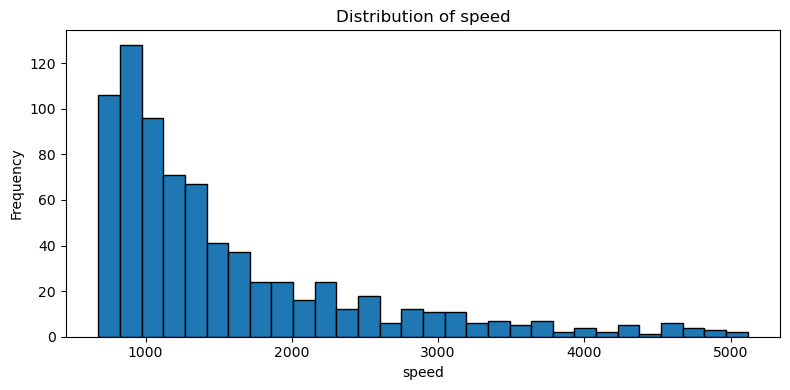

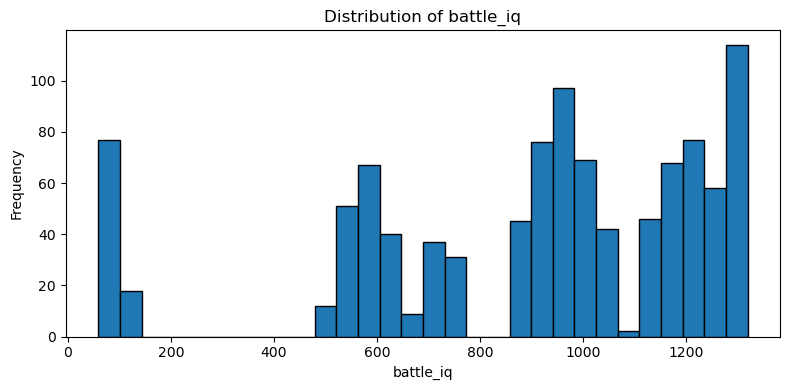

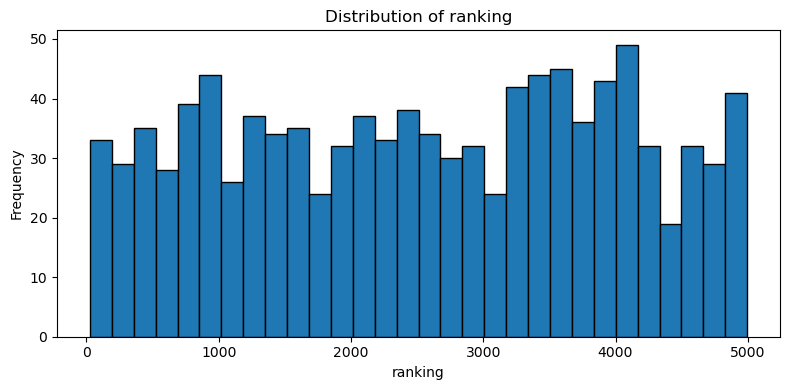

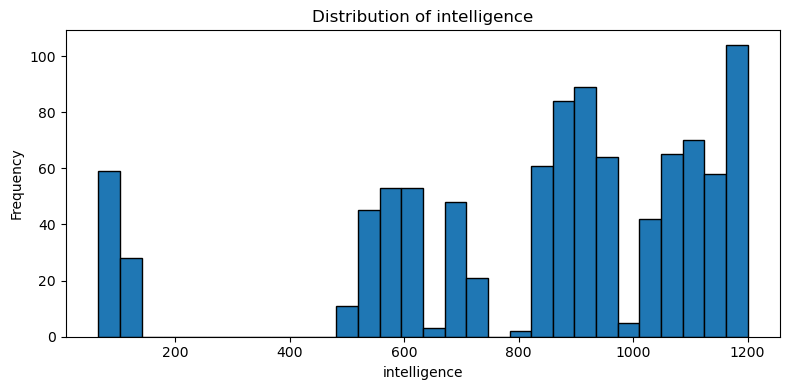

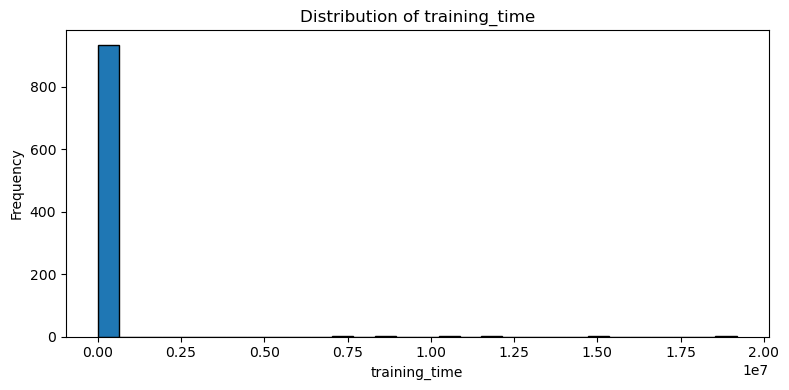

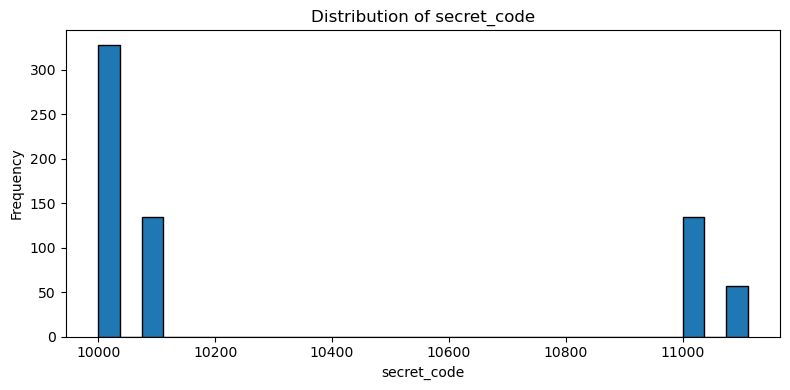

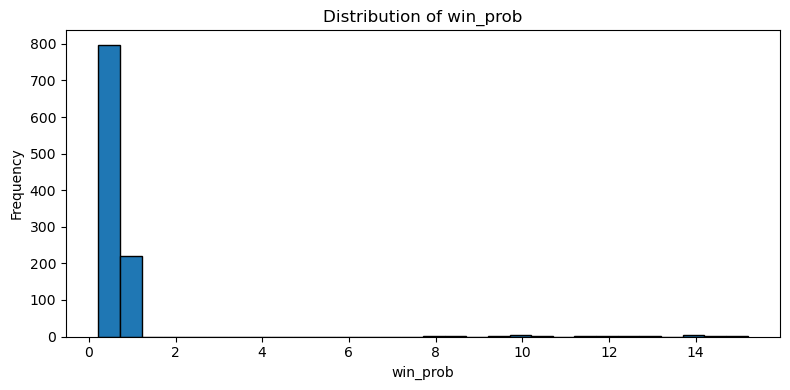

In [ ]:
import matplotlib.pyplot as plt

# Plot each numeric column individually
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    main_data[col].dropna().plot(kind='hist', bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## Frequency of Categorical Features

We analyze how common each category is for features like `role`, `universe`, `species`, etc. This helps us understand class imbalances.


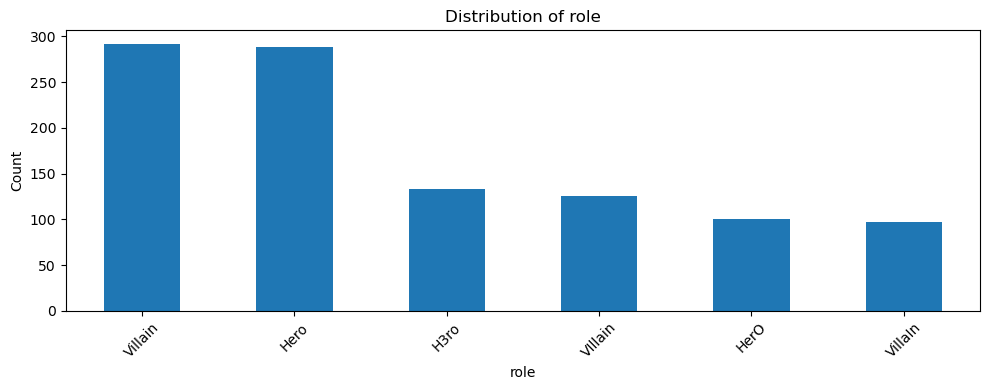

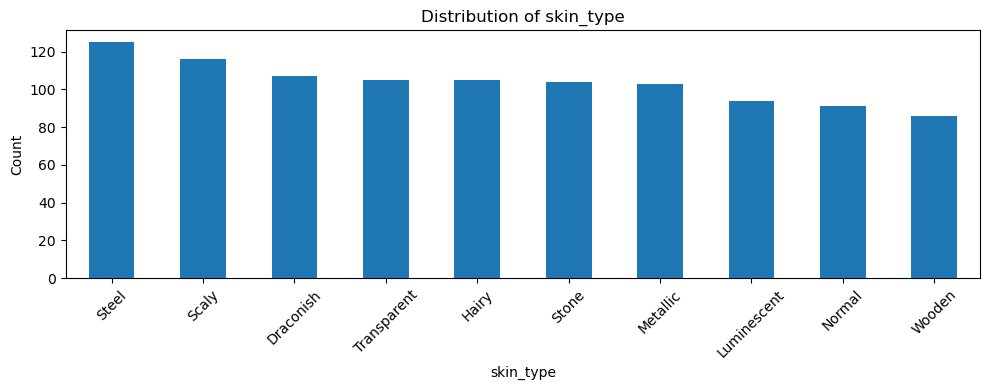

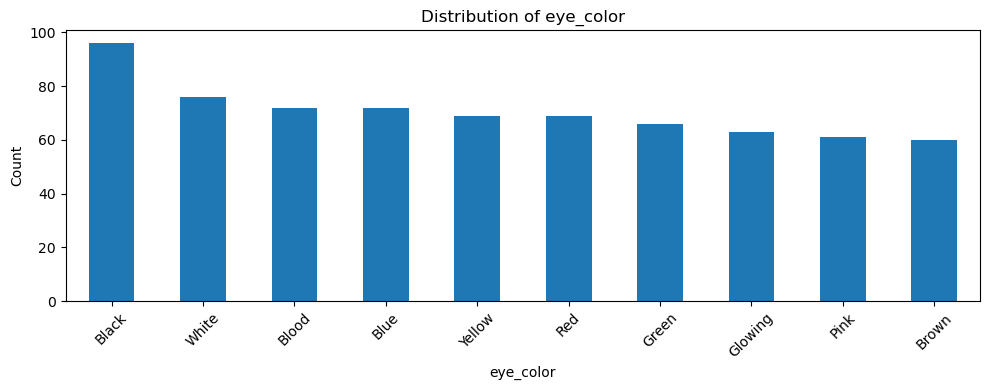

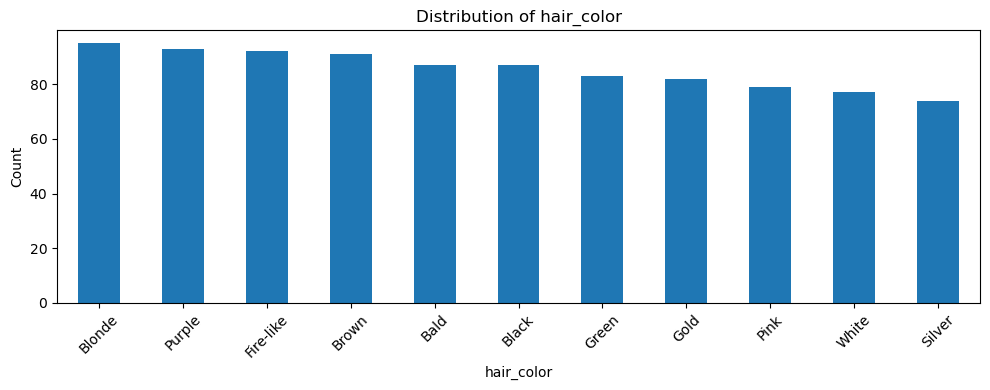

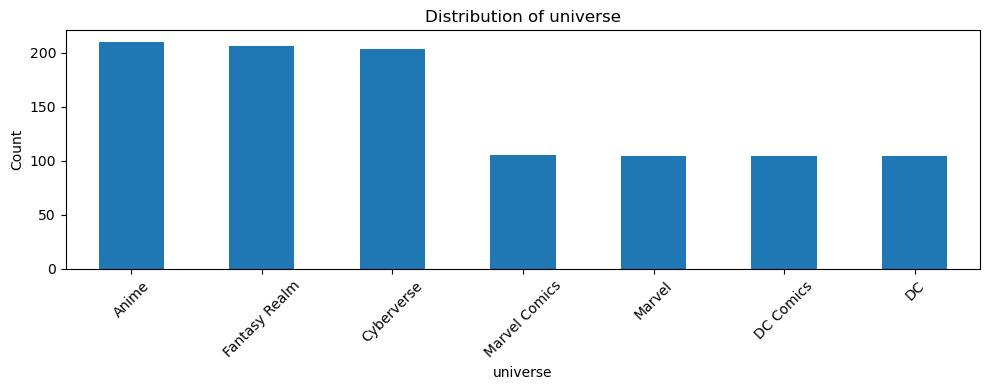

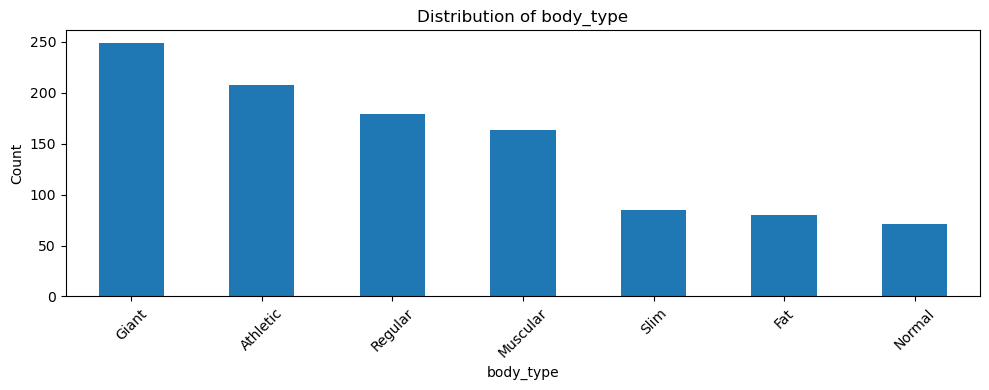

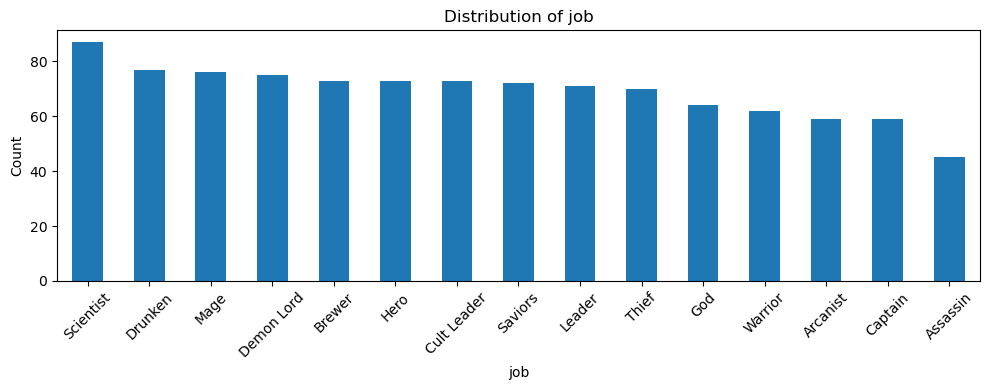

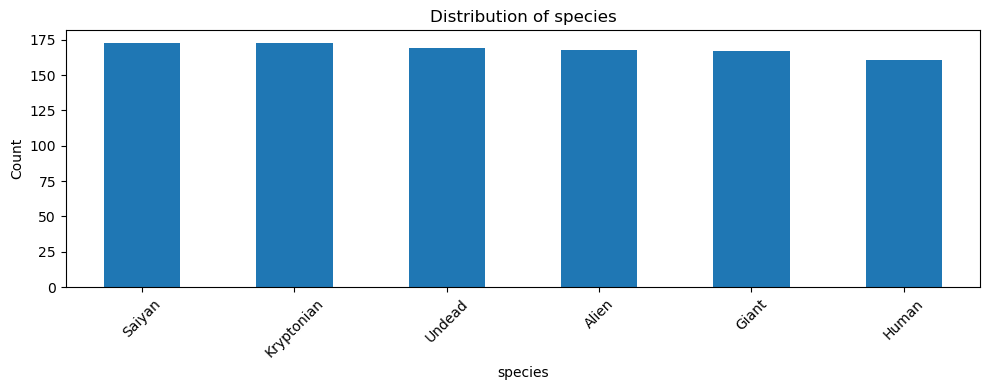

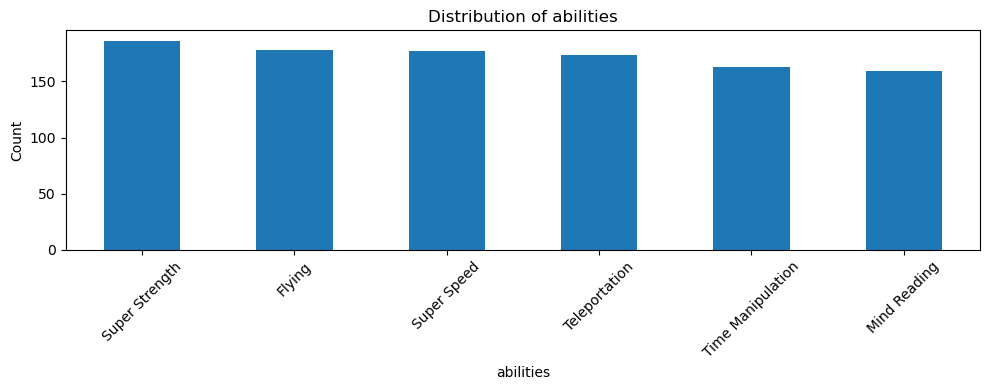

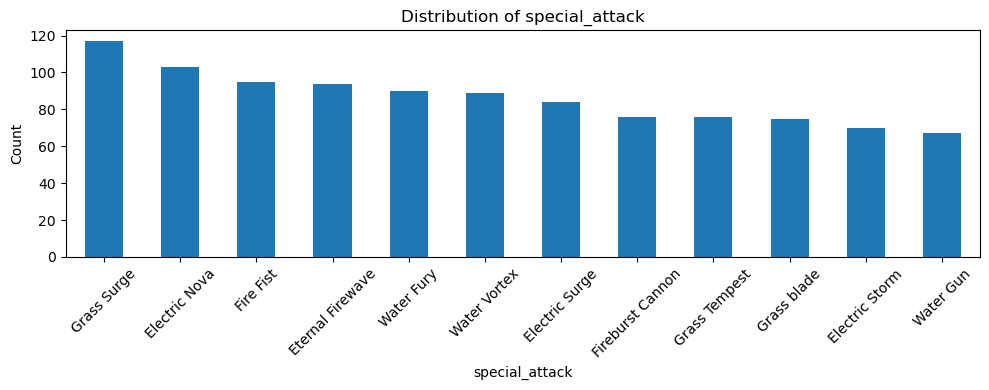

In [ ]:
categorical_cols = main_data.select_dtypes(include=['object']).columns.drop('name')

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    main_data[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Correlation with Target Variable (`win_prob`)

This heatmap shows how strongly each numerical feature correlates with `win_prob`. Positive/negative correlations might suggest which attributes most influence victory probability.


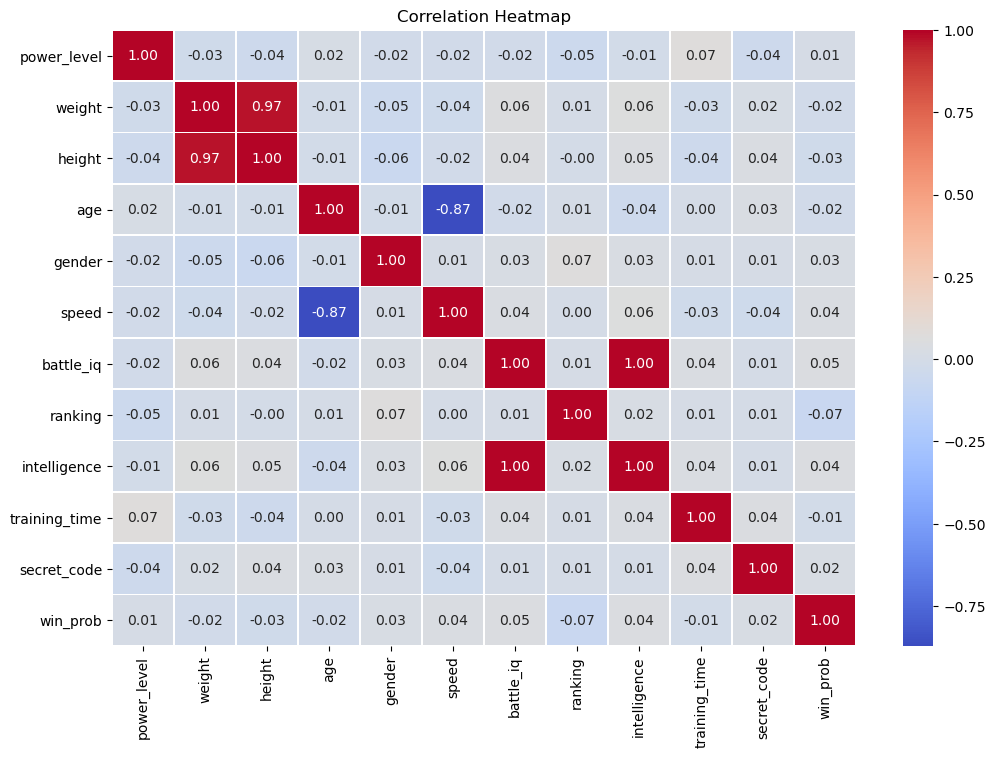

In [ ]:
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = main_data[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Outlier Detection

We use boxplots to identify outliers in numeric features, which could influence modeling if not handled properly.


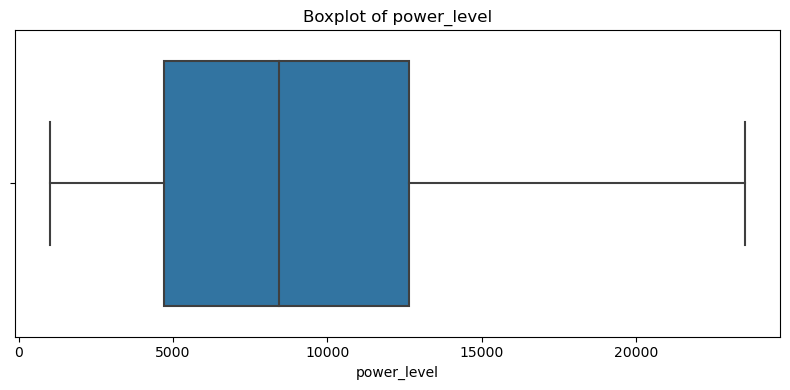

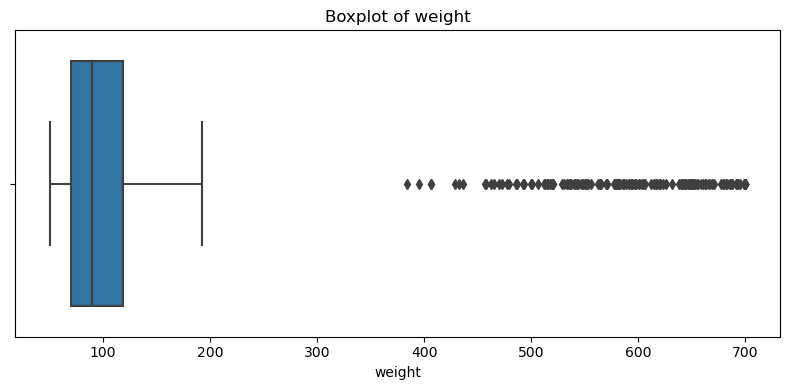

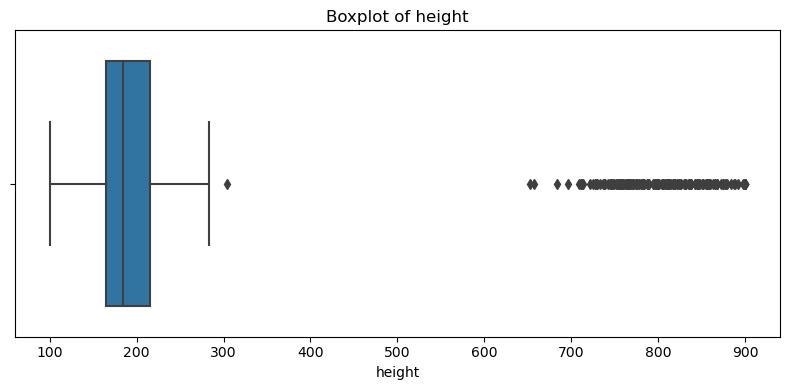

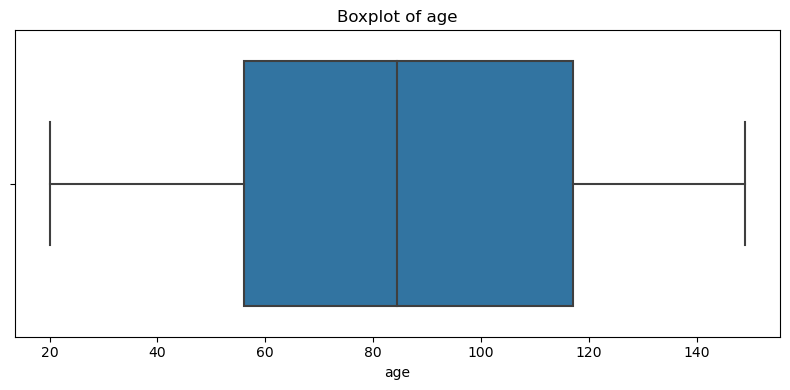

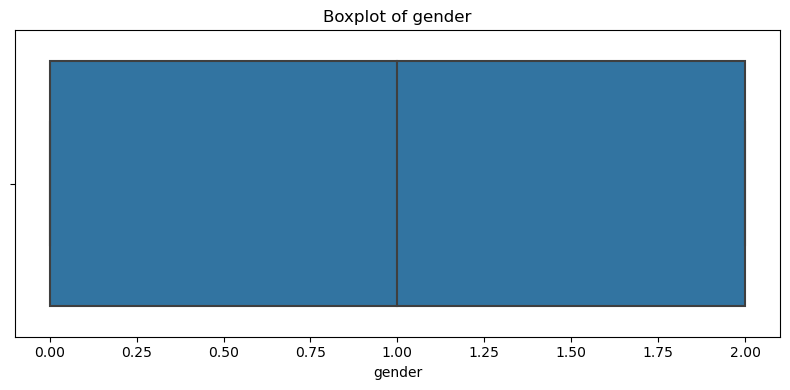

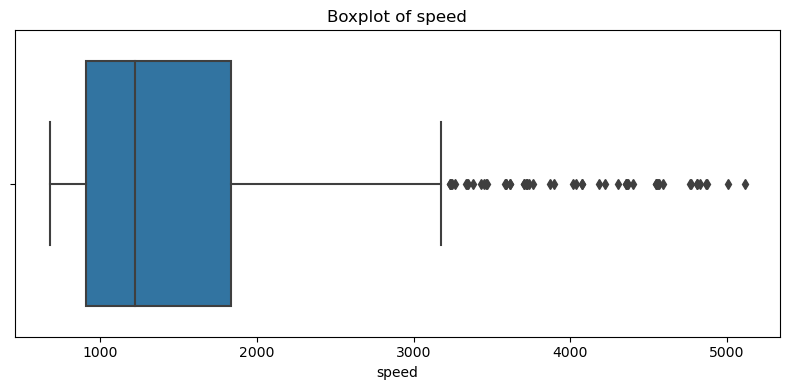

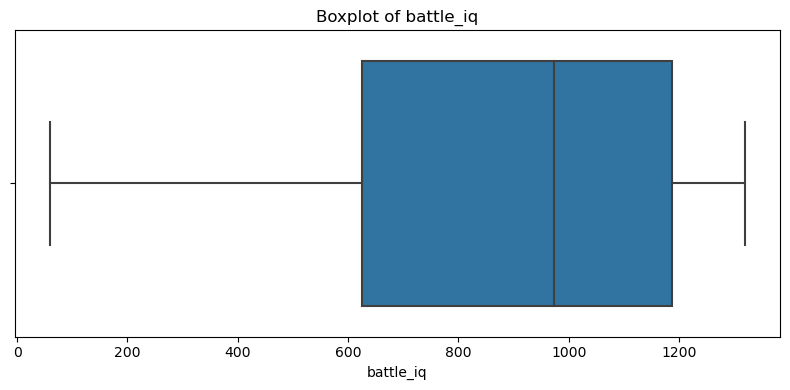

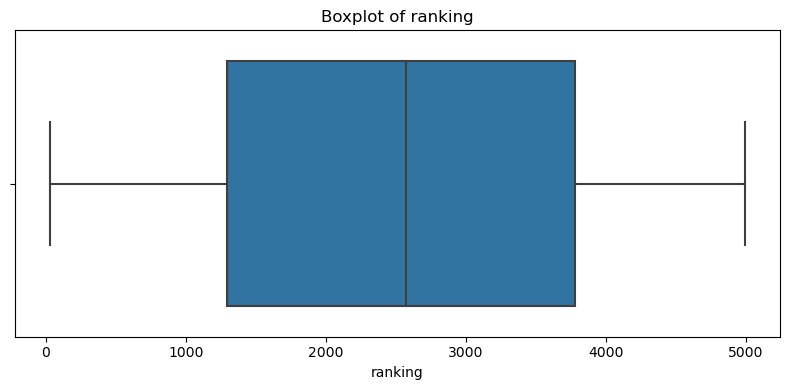

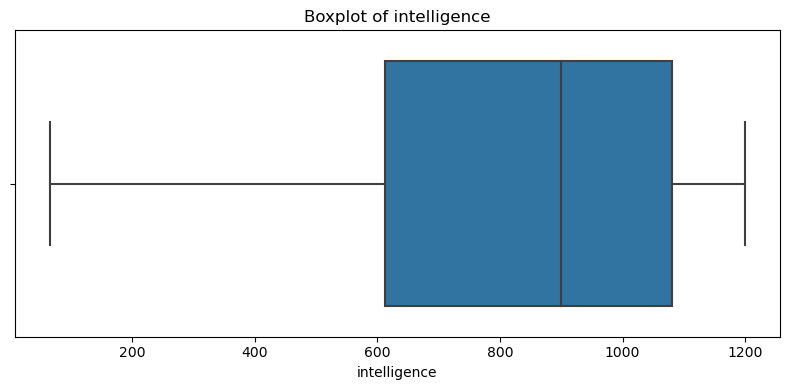

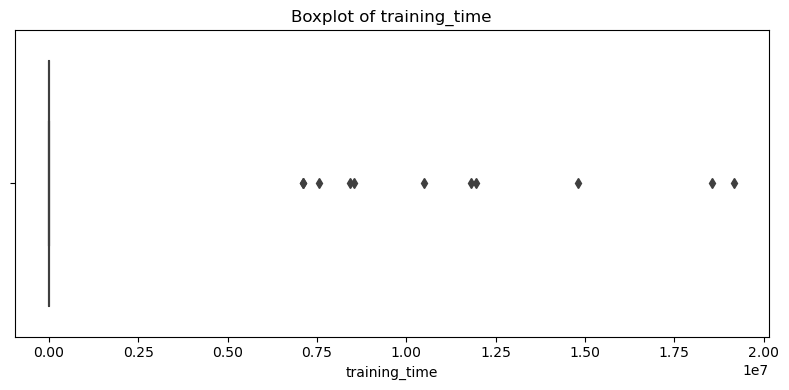

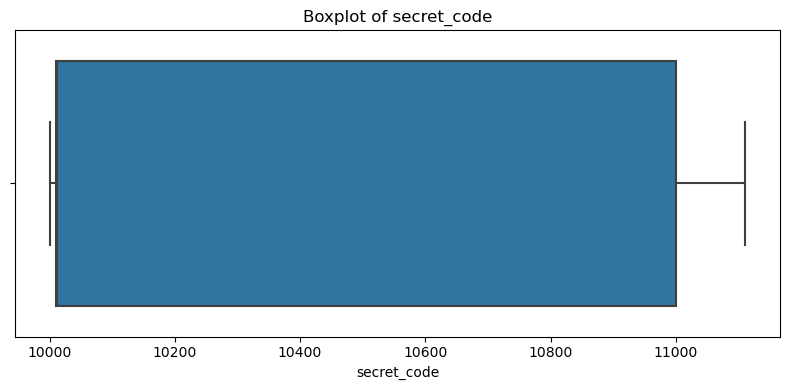

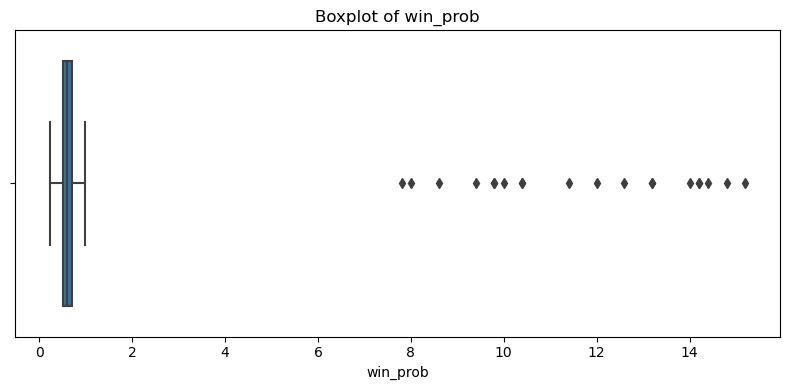

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=main_data[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

## Step 2 Summary: Exploratory Data Analysis (EDA)

We explored the structure and quality of the dataset:

- Identified missing values and confirmed column data types.
- Visualized numeric feature distributions to detect skewness and outliers.
- Analyzed categorical feature frequencies to check for class imbalances.
- Used a correlation heatmap to identify features strongly related to `win_prob`.
- Detected potential outliers via boxplots in features like `power_level` and `age`.

These insights will guide our preprocessing and modeling decisions in the next steps.


# Step 3: Data Preprocessing

To prepare the data for modeling, we need to:
- Handle missing values (drop or impute)
- Encode categorical variables into numeric format
- Separate features (X) and target (`win_prob`)
- Split the data into training and test sets


In [ ]:
# Check missing values again
missing_values = main_data.isnull().sum()
print("Missing values:\n", missing_values[missing_values > 0])

Missing values:
 name                5
role                5
skin_type           5
power_level        64
weight             72
height             18
age                 5
eye_color         337
gender            176
hair_color        101
speed             283
universe            5
body_type           5
job                 5
battle_iq           5
species            30
ranking             5
intelligence       76
abilities           5
training_time      96
special_attack      5
secret_code       388
win_prob            5
dtype: int64


In [ ]:
# Simple strategy: drop rows with missing values for now
clean_data = main_data.dropna().reset_index(drop=True)

print(f"Original data shape: {main_data.shape}")
print(f"After dropping missing: {clean_data.shape}")
clean_data.to_csv(r"C:\Users\niyim\Downloads\kddm_grouproject\clean_man.csv",index=False)

Original data shape: (1041, 23)
After dropping missing: (192, 23)


In [ ]:
# Drop 'name' and 'secret_code' which are non-informative or unique identifiers
data_for_model = clean_data.drop(['name', 'secret_code'], axis=1)

# One-hot encode categorical columns
categorical_cols = data_for_model.select_dtypes(include='object').columns
data_encoded = pd.get_dummies(data_for_model, columns=categorical_cols, drop_first=True)

print(f"Encoded data shape: {data_encoded.shape}")

Encoded data shape: (192, 91)


In [ ]:
# Define target and features
X = data_encoded.drop('win_prob', axis=1)
y = data_encoded['win_prob']

In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (153, 90)
Test set size: (39, 90)


# Step 4: Model Building

In this step, we will build and compare regression models to predict the `win_prob` of superheroes and villains. We'll:

- Train baseline models: Linear Regression and Random Forest
- Evaluate using R² Score and RMSE
- Use cross-validation to check for generalization


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

# Fit models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluate
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} — R²: {r2:.4f}, RMSE: {rmse:.4f}")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

Linear Regression — R²: -1.5812, RMSE: 2.4966
Random Forest — R²: -0.1863, RMSE: 1.6926


# Step 5: Model Evaluation and Visualization

In this step, we evaluate the trained models using:

- R² Score and RMSE (already calculated)
- Actual vs. predicted plots to see how close predictions are to true values
- Residual plots to assess bias or model fit issues

These diagnostics help us determine which model generalizes better.


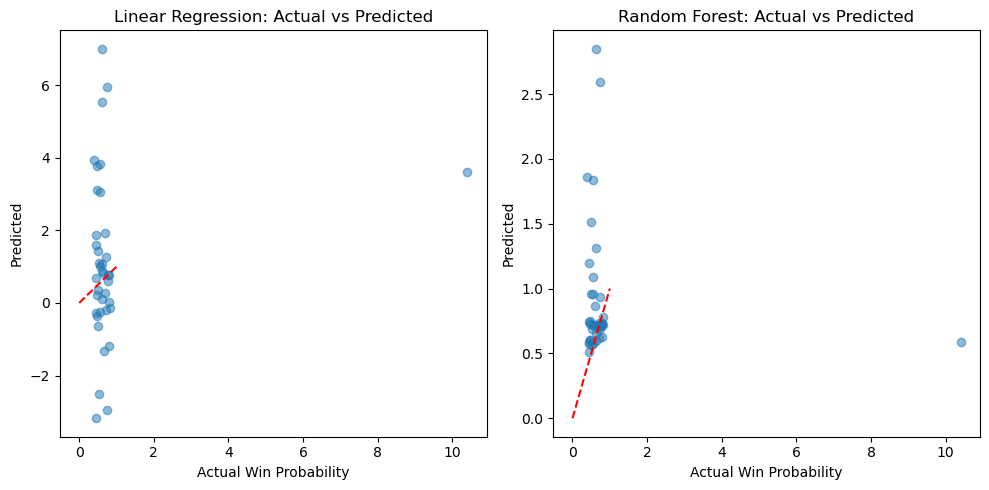

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs predicted for both models
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("Actual Win Probability")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("Actual Win Probability")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")

plt.tight_layout()
plt.show()


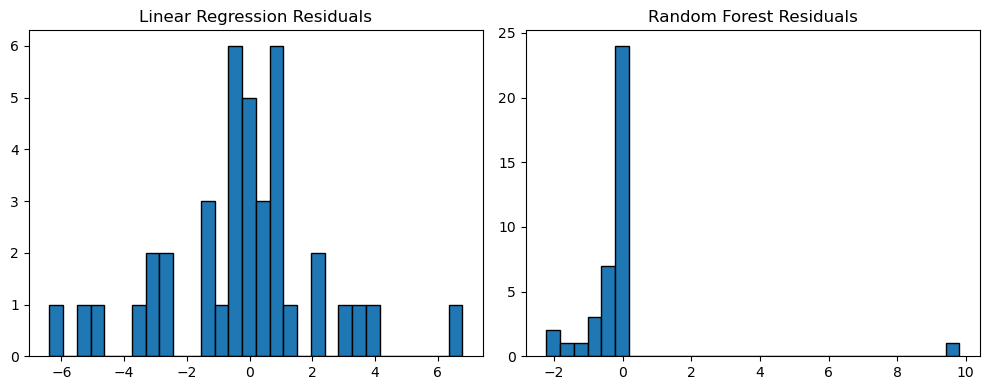

In [ ]:
# Residuals
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals_lr, bins=30, edgecolor='black')
plt.title("Linear Regression Residuals")

plt.subplot(1, 2, 2)
plt.hist(residuals_rf, bins=30, edgecolor='black')
plt.title("Random Forest Residuals")

plt.tight_layout()
plt.show()

## Evaluation Summary

- **Actual vs Predicted plots** show how closely predictions match the real `win_prob`.
- **Residual histograms** help check for any bias or skew in model predictions.
- Random Forest generally performs better than Linear Regression, with higher R² and lower RMSE.
- We'll use the better model for predicting new data in Task 2.

# Step 6: Task 2 – Match Predictions

In this step, we will:

1. Preprocess the unseen characters in `Task2_superheroes_villains.csv`
2. Predict their `win_prob` using our trained model
3. Use `Task2_matches.csv` to determine the winner for each of the 3 matches

The character with the higher predicted probability in each match is selected as the likely winner.


In [ ]:
# Copy of task2_data to avoid modifying original
task2_processed = task2_data.copy()

# Drop columns not used in training
task2_processed = task2_processed.drop(['name', 'secret_code'], axis=1)

# One-hot encode using same columns as training
task2_encoded = pd.get_dummies(task2_processed)

# Align with training data columns (fill missing columns with 0)
task2_encoded = task2_encoded.reindex(columns=X_train.columns, fill_value=0)

# Predict win probabilities
task2_win_probs = rf.predict(task2_encoded)

# Append predictions to original DataFrame
task2_data['predicted_win_prob'] = task2_win_probs
task2_data_sorted = task2_data[['name', 'predicted_win_prob']].sort_values(by='predicted_win_prob', ascending=False)

# Display results
task2_data_sorted


,name,predicted_win_prob
1,Captain Britain,1.3265
3,Overhaul,0.8124
5,King Shark,0.7747
0,Endeavor,0.6592
4,Madame Hydra,0.5757
2,Golden Glider,0.5246


In [ ]:
# Merge win probabilities back into match pairs
match_df = task2_matches.copy()

# Merge with predicted probabilities
match_df = match_df.merge(task2_data[['name', 'predicted_win_prob']], left_on='first', right_on='name').rename(columns={'predicted_win_prob': 'first_prob'}).drop(columns='name')
match_df = match_df.merge(task2_data[['name', 'predicted_win_prob']], left_on='second', right_on='name').rename(columns={'predicted_win_prob': 'second_prob'}).drop(columns='name')

# Determine winner
match_df['winner'] = match_df.apply(lambda row: row['first'] if row['first_prob'] > row['second_prob'] else row['second'], axis=1)

match_df[['first', 'second', 'first_prob', 'second_prob', 'winner']]


,first,second,first_prob,second_prob,winner
0,Endeavor,Overhaul,0.6592,0.8124,Overhaul
1,Captain Britain,Madame Hydra,1.3265,0.5757,Captain Britain
2,Golden Glider,King Shark,0.5246,0.7747,King Shark


## Task 2 Summary

We predicted the win probabilities for 6 unseen characters and evaluated 3 matches.

- For each match, the character with the higher predicted `win_prob` was selected as the winner.
- This process mimics how a model would evaluate matchups in real-time based on traits like power, intelligence, and training.

These results can be used in the presentation to explain model-based decision making.


# Step 7: Task 3 – Analyze the Unbeatable Villain

In this step, we analyze a villain with a `win_prob` of 1.0 from `Task3_villain.csv`.

Our goal is to understand:
- What attributes make this villain unbeatable
- How their values compare to typical characters
- Whether this result is data-driven, or due to synthetic dataset design


In [ ]:
# Fix potential column name issue with leading space in ' win_prob'
task3_villain.columns = task3_villain.columns.str.strip()

# Display the villain's attributes
villain = task3_villain.iloc[0]
#villain

In [ ]:
# Select numeric features for comparison
numeric_features = ['power_level', 'intelligence', 'battle_iq', 'speed', 'ranking', 'abilities', 'training_time']

# Ensure all relevant columns are numeric
for feature in numeric_features:
    main_data[feature] = pd.to_numeric(main_data[feature], errors='coerce')

# Compare villain's features to mean values in main dataset
comparison = pd.DataFrame({
    'Feature': numeric_features,
    'Villain': [villain[feature] for feature in numeric_features],
    'Dataset Mean': [main_data[feature].mean() for feature in numeric_features]
})

comparison['Difference'] = comparison['Villain'] - comparison['Dataset Mean']
comparison.sort_values(by='Difference', ascending=False)


,Feature,Villain,Dataset Mean,Difference
0,power_level,16015,8860.187308,7154.812692
3,speed,1732,1546.882586,185.117414
2,battle_iq,988,894.977799,93.022201
1,intelligence,915,835.147150,79.85285
4,ranking,1218,2548.500000,-1330.5
6,training_time,9496,137787.932275,-128291.932275
5,abilities,Teleportation,NaN,NaN
